# Comparaison MobileNetV3 vs EfficientNetB0

Ce notebook compare les performances des modèles basés sur **MobileNetV3** et **EfficientNetB0** pour la prédiction d'âge, genre et ethnicité.

## Objectifs

1. Comparer les métriques de précision (MAE, Accuracy, F1-Score)
2. Comparer les temps d'inférence
3. Comparer les tailles de modèles
4. Visualiser les prédictions sur des images de test


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import time
from PIL import Image
from pathlib import Path
import pandas as pd

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

2026-01-28 11:29:30.994243: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-28 11:29:31.252891: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-28 11:29:32.383982: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Configuration et Chargement des Modèles


In [ ]:
# Configuration
ARTIFACTS_DIR = Path("artifacts")
DATA_DIR = Path("data/UTKFace")
IMG_SIZE = 128

# Modèles à comparer
MODELS = {
    "EfficientNet V4 (Multitask)": {
        "tflite": "multitask_model_v4.tflite",
        "info": "multitask_v4_model_info.json",
        "backbone": "EfficientNetB0",
    },
    "MobileNet V1 (Multitask)": {
        "tflite": "mobilenet_model.tflite",
        "info": "mobilenet_model_info.json",
        "backbone": "MobileNetV3Large",
    },
    "MobileNet V5 (Multitask)": {
        "tflite": "multitask_model_v5_mobilenet.tflite",
        "info": "multitask_v5_mobilenet_info.json",
        "backbone": "MobileNetV3Small",
    },
}

# Vérifier que les fichiers existent
for name, config in MODELS.items():
    tflite_path = ARTIFACTS_DIR / config["tflite"]
    info_path = ARTIFACTS_DIR / config["info"]
    print(f"{name}:")
    print(f"  TFLite: {'✓' if tflite_path.exists() else '✗'} ({tflite_path})")
    print(f"  Info: {'✓' if info_path.exists() else '✗'} ({info_path})")

EfficientNet V4 (Multitask):
  TFLite: ✓ (artifacts/multitask_model_v4.tflite)
  Info: ✓ (artifacts/multitask_v4_model_info.json)
MobileNet V1 (Multitask):
  TFLite: ✓ (artifacts/mobilenet_model.tflite)
  Info: ✓ (artifacts/mobilenet_model_info.json)
MobileNet V5 (Multitask):
  TFLite: ✓ (artifacts/multitask_model_v5_mobilenet.tflite)
  Info: ✓ (artifacts/multitask_v5_mobilenet_info.json)


In [3]:
# Charger les informations des modèles
model_infos = {}
for name, config in MODELS.items():
    info_path = ARTIFACTS_DIR / config["info"]
    if info_path.exists():
        with open(info_path, "r") as f:
            model_infos[name] = json.load(f)
        print(f"\n{name}:")
        print(json.dumps(model_infos[name].get("metrics", {}), indent=2))


EfficientNet V4 (Multitask):
{
  "age_mae": 6.650386333465576,
  "gender_accuracy": 0.7814814814814814,
  "gender_f1": 0.751653638003608,
  "ethnicity_accuracy": 0.6433862433862434,
  "ethnicity_f1_macro": 0.6347714350774047
}

MobileNet V1 (Multitask):
{
  "age_mae": 6.4678778648376465,
  "age_rmse": 9.201828956604004,
  "gender_accuracy": 0.8358251057827927,
  "gender_f1": 0.8185785536159601,
  "ethnicity_accuracy": 0.6245416078984485,
  "ethnicity_f1_macro": 0.5605490478140922
}

MobileNet V5 (Multitask):
{
  "age_mae": 7.874427795410156,
  "age_rmse": 10.992684364318848,
  "gender_accuracy": 0.7788359788359789,
  "gender_f1": 0.7546948356807511,
  "ethnicity_accuracy": 0.5920634920634921,
  "ethnicity_f1_macro": 0.5872323550793177
}


In [ ]:
# Charger les interpréteurs TFLite
interpreters = {}

for name, config in MODELS.items():
    tflite_path = ARTIFACTS_DIR / config["tflite"]
    if tflite_path.exists():
        interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
        interpreter.allocate_tensors()
        interpreters[name] = interpreter

        # Afficher les détails
        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()

        # Taille du fichier
        size_mb = os.path.getsize(tflite_path) / (1024 * 1024)

        print(f"\n{name}:")
        print(f"  Taille: {size_mb:.2f} MB")
        print(f"  Input shape: {input_details[0]['shape']}")
        print(f"  Outputs: {len(output_details)}")
        for i, out in enumerate(output_details):
            print(f"    [{i}] {out['name']}: shape={out['shape']}")


EfficientNet V4 (Multitask):
  Taille: 10.77 MB
  Input shape: [  1 128 128   3]
  Outputs: 3
    [0] StatefulPartitionedCall_1:1: shape=[1 1]
    [1] StatefulPartitionedCall_1:0: shape=[1 1]
    [2] StatefulPartitionedCall_1:2: shape=[1 4]

MobileNet V1 (Multitask):
  Taille: 7.03 MB
  Input shape: [  1 128 128   3]
  Outputs: 3
    [0] StatefulPartitionedCall_1:1: shape=[1 1]
    [1] StatefulPartitionedCall_1:0: shape=[1 1]
    [2] StatefulPartitionedCall_1:2: shape=[1 5]

MobileNet V5 (Multitask):
  Taille: 3.51 MB
  Input shape: [  1 128 128   3]
  Outputs: 3
    [0] StatefulPartitionedCall_1:1: shape=[1 1]
    [1] StatefulPartitionedCall_1:0: shape=[1 1]
    [2] StatefulPartitionedCall_1:2: shape=[1 4]


/home/optimalako/Projet/SAE/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 2. Comparaison des Métriques Enregistrées


In [ ]:
# Créer un tableau comparatif des métriques
comparison_data = []

for name, config in MODELS.items():
    if name in model_infos:
        metrics = model_infos[name].get("metrics", {})
        tflite_path = ARTIFACTS_DIR / config["tflite"]
        size_mb = (
            os.path.getsize(tflite_path) / (1024 * 1024) if tflite_path.exists() else 0
        )

        comparison_data.append(
            {
                "Modèle": name,
                "Backbone": config["backbone"],
                "Age MAE": metrics.get("age_mae", metrics.get("mae", "N/A")),
                "Genre Acc": metrics.get(
                    "gender_accuracy", metrics.get("accuracy", "N/A")
                ),
                "Genre F1": metrics.get("gender_f1", metrics.get("f1", "N/A")),
                "Eth. Acc": metrics.get("ethnicity_accuracy", "N/A"),
                "Eth. F1": metrics.get("ethnicity_f1_macro", "N/A"),
                "Taille (MB)": round(size_mb, 2),
            }
        )

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "=" * 80)
print("COMPARAISON DES MÉTRIQUES")
print("=" * 80)
display(df_comparison)


COMPARAISON DES MÉTRIQUES


,Modèle,Backbone,Age MAE,Genre Acc,Genre F1,Eth. Acc,Eth. F1,Taille (MB)
0,EfficientNet V4 (Multitask),EfficientNetB0,6.650386,0.781481,0.751654,0.643386,0.634771,10.77
1,MobileNet V1 (Multitask),MobileNetV3Large,6.467878,0.835825,0.818579,0.624542,0.560549,7.03
2,MobileNet V5 (Multitask),MobileNetV3Small,7.874428,0.778836,0.754695,0.592063,0.587232,3.51


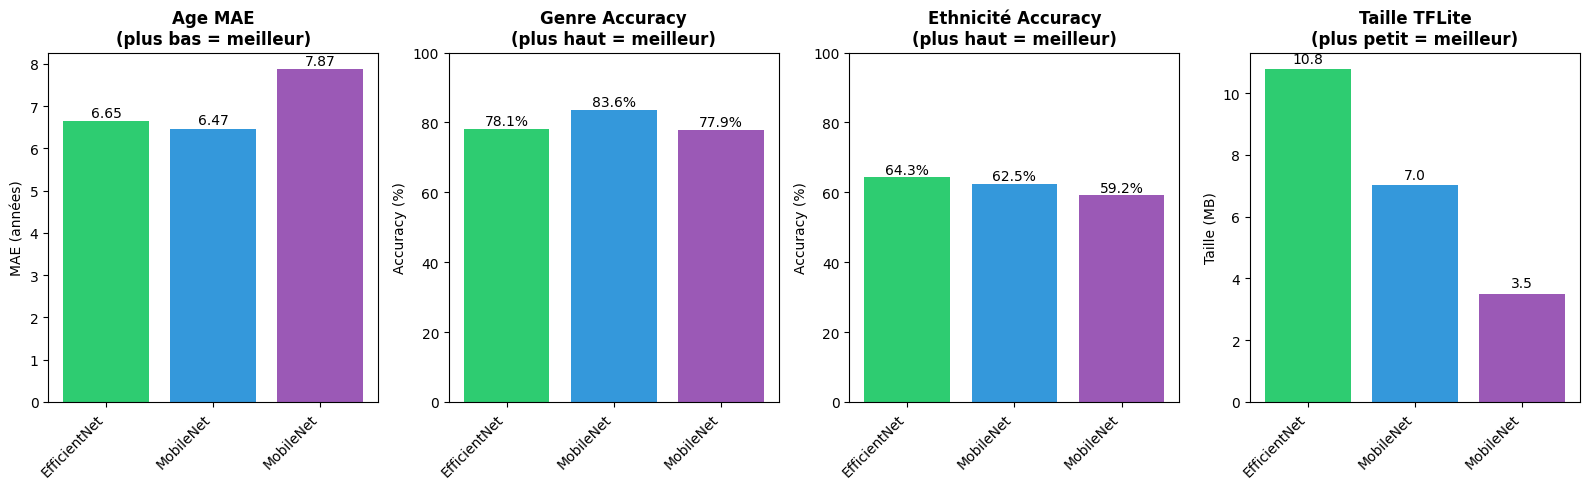

In [ ]:
# Visualisation des métriques
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

models = df_comparison["Modèle"].values
colors = ["#2ecc71", "#3498db", "#9b59b6"]

# Age MAE (plus bas = meilleur)
ax = axes[0]
values = df_comparison["Age MAE"].values
bars = ax.bar(range(len(models)), values, color=colors)
ax.set_ylabel("MAE (années)")
ax.set_title("Age MAE\n(plus bas = meilleur)", fontweight="bold")
ax.set_xticks(range(len(models)))
ax.set_xticklabels([m.split()[0] for m in models], rotation=45, ha="right")
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{val:.2f}",
        ha="center",
        fontsize=10,
    )

# Genre Accuracy
ax = axes[1]
values = df_comparison["Genre Acc"].values * 100
bars = ax.bar(range(len(models)), values, color=colors)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Genre Accuracy\n(plus haut = meilleur)", fontweight="bold")
ax.set_xticks(range(len(models)))
ax.set_xticklabels([m.split()[0] for m in models], rotation=45, ha="right")
ax.set_ylim(0, 100)
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{val:.1f}%",
        ha="center",
        fontsize=10,
    )

# Ethnicité Accuracy
ax = axes[2]
values = df_comparison["Eth. Acc"].values * 100
bars = ax.bar(range(len(models)), values, color=colors)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Ethnicité Accuracy\n(plus haut = meilleur)", fontweight="bold")
ax.set_xticks(range(len(models)))
ax.set_xticklabels([m.split()[0] for m in models], rotation=45, ha="right")
ax.set_ylim(0, 100)
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{val:.1f}%",
        ha="center",
        fontsize=10,
    )

# Taille du modèle
ax = axes[3]
values = df_comparison["Taille (MB)"].values
bars = ax.bar(range(len(models)), values, color=colors)
ax.set_ylabel("Taille (MB)")
ax.set_title("Taille TFLite\n(plus petit = meilleur)", fontweight="bold")
ax.set_xticks(range(len(models)))
ax.set_xticklabels([m.split()[0] for m in models], rotation=45, ha="right")
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{val:.1f}",
        ha="center",
        fontsize=10,
    )

plt.tight_layout()
plt.savefig(
    "artifacts/mobilenet_vs_efficientnet_metrics.png", dpi=150, bbox_inches="tight"
)
plt.show()

## 3. Préparation des Données de Test


In [ ]:
# Charger un échantillon d'images de test
def parse_utkface_filename(filename):
    """Parse UTKFace filename: [age]_[gender]_[race]_[date&time].jpg"""
    try:
        parts = filename.split("_")
        age = int(parts[0])
        gender = int(parts[1])  # 0=Male, 1=Female
        race = int(parts[2])  # 0=White, 1=Black, 2=Asian, 3=Indian, 4=Others
        return age, gender, race
    except:
        return None, None, None


def load_test_images(data_dir, num_samples=100, seed=42):
    """Charge un échantillon équilibré d'images de test"""
    np.random.seed(seed)

    all_images = list(Path(data_dir).glob("*.jpg"))
    valid_images = []

    for img_path in all_images:
        age, gender, race = parse_utkface_filename(img_path.name)
        if (
            age is not None and race < 4
        ):  # Exclure "Others" pour la comparaison équitable
            valid_images.append((img_path, age, gender, race))

    # Échantillon aléatoire
    selected = np.random.choice(
        len(valid_images), min(num_samples, len(valid_images)), replace=False
    )
    return [valid_images[i] for i in selected]


test_images = load_test_images(DATA_DIR, num_samples=200)
print(f"Images de test chargées: {len(test_images)}")

# Statistiques des images de test
genders = [g for _, _, g, _ in test_images]
races = [r for _, _, _, r in test_images]
ages = [a for _, a, _, _ in test_images]

print(f"\nRépartition Genre: Male={genders.count(0)}, Female={genders.count(1)}")
print(
    f"Répartition Ethnicité: White={races.count(0)}, Black={races.count(1)}, Asian={races.count(2)}, Indian={races.count(3)}"
)
print(f"Age: min={min(ages)}, max={max(ages)}, mean={np.mean(ages):.1f}")

Images de test chargées: 200

Répartition Genre: Male=104, Female=96
Répartition Ethnicité: White=88, Black=49, Asian=29, Indian=34
Age: min=1, max=116, mean=35.9


In [ ]:
def preprocess_image(img_path, img_size=128):
    """Prétraitement de l'image pour TFLite"""
    img = Image.open(img_path).convert("RGB")
    img = img.resize((img_size, img_size))
    img_array = np.array(img, dtype=np.float32)
    return img_array[np.newaxis, ...]  # Ajouter dimension batch


# Test de prétraitement
test_img = preprocess_image(test_images[0][0])
print(f"Shape: {test_img.shape}, Range: [{test_img.min():.0f}, {test_img.max():.0f}]")

Shape: (1, 128, 128, 3), Range: [0, 209]


## 4. Benchmark de Temps d'Inférence


In [ ]:
def run_inference(interpreter, img_array):
    """Exécute l'inférence et retourne les prédictions"""
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    interpreter.set_tensor(input_details[0]["index"], img_array)
    interpreter.invoke()

    outputs = []
    for out in output_details:
        outputs.append(interpreter.get_tensor(out["index"]))

    return outputs


def benchmark_model(interpreter, test_images, num_runs=50):
    """Benchmark du temps d'inférence"""
    times = []

    # Warmup
    img = preprocess_image(test_images[0][0])
    for _ in range(5):
        run_inference(interpreter, img)

    # Benchmark
    for i in range(num_runs):
        img = preprocess_image(test_images[i % len(test_images)][0])
        start = time.perf_counter()
        run_inference(interpreter, img)
        end = time.perf_counter()
        times.append((end - start) * 1000)  # en ms

    return {
        "mean": np.mean(times),
        "std": np.std(times),
        "min": np.min(times),
        "max": np.max(times),
    }


# Benchmark de tous les modèles
benchmark_results = {}
print("Benchmark en cours...\n")

for name, interpreter in interpreters.items():
    print(f"Testing {name}...")
    results = benchmark_model(interpreter, test_images)
    benchmark_results[name] = results
    print(f"  Temps moyen: {results['mean']:.2f} ± {results['std']:.2f} ms")
    print(f"  Range: [{results['min']:.2f}, {results['max']:.2f}] ms")

Benchmark en cours...

Testing EfficientNet V4 (Multitask)...
  Temps moyen: 5.33 ± 0.37 ms
  Range: [4.66, 6.53] ms
Testing MobileNet V1 (Multitask)...
  Temps moyen: 2.31 ± 0.23 ms
  Range: [1.95, 2.96] ms
Testing MobileNet V5 (Multitask)...
  Temps moyen: 0.70 ± 0.19 ms
  Range: [0.53, 1.29] ms


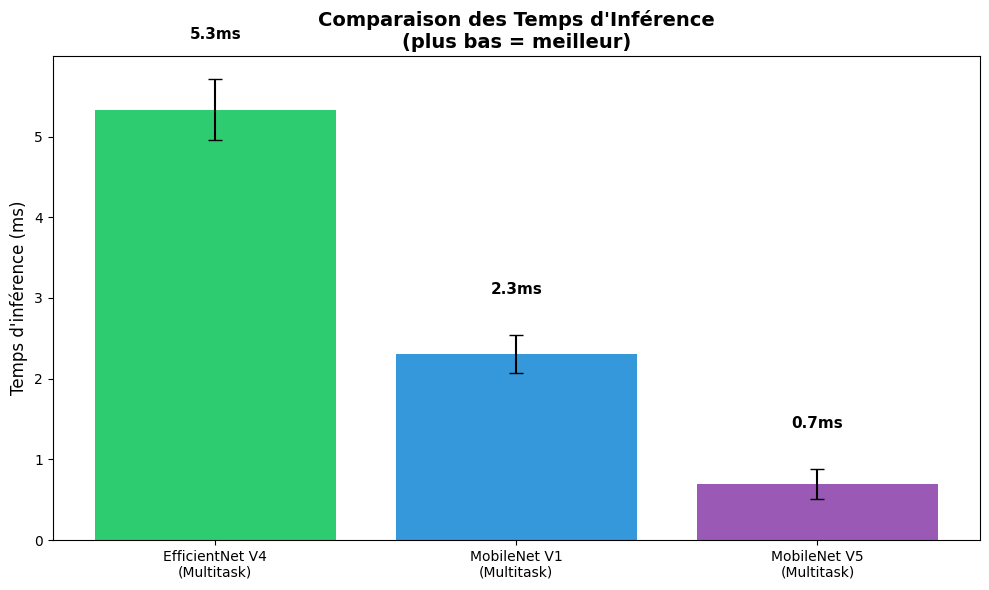

In [ ]:
# Visualisation des temps d'inférence
fig, ax = plt.subplots(figsize=(10, 6))

names = list(benchmark_results.keys())
means = [benchmark_results[n]["mean"] for n in names]
stds = [benchmark_results[n]["std"] for n in names]

bars = ax.bar(
    range(len(names)), means, yerr=stds, capsize=5, color=colors[: len(names)]
)
ax.set_ylabel("Temps d'inférence (ms)", fontsize=12)
ax.set_title(
    "Comparaison des Temps d'Inférence\n(plus bas = meilleur)",
    fontsize=14,
    fontweight="bold",
)
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.replace(" (", "\n(") for n in names], fontsize=10)

for bar, mean, std in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + std + 0.5,
        f"{mean:.1f}ms",
        ha="center",
        fontsize=11,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("artifacts/inference_time_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Évaluation sur les Images de Test


In [ ]:
def interpret_outputs(outputs, model_name, model_info):
    """Interprète les sorties du modèle selon son info JSON"""
    # Les modèles ont des ordres de sortie différents
    # Regarder le model_info pour déterminer l'ordre

    if "v4" in model_name.lower() or "v5" in model_name.lower():
        # V4/V5: [gender, age, ethnicity]
        gender_prob = outputs[0][0][0]
        age = outputs[1][0][0]
        eth_probs = outputs[2][0]
    else:
        # MobileNet V1: [age, gender, ethnicity]
        age = outputs[0][0][0]
        gender_prob = outputs[1][0][0]
        eth_probs = outputs[2][0]

    gender = 1 if gender_prob > 0.5 else 0
    ethnicity = np.argmax(eth_probs)

    return {
        "age": float(age),
        "gender": gender,
        "gender_prob": float(gender_prob),
        "ethnicity": int(ethnicity),
        "eth_probs": eth_probs.tolist(),
    }


# Évaluer tous les modèles sur les images de test
all_predictions = {name: [] for name in interpreters.keys()}
ground_truth = []

print("Évaluation en cours...")
for img_path, true_age, true_gender, true_race in test_images:
    ground_truth.append(
        {"age": true_age, "gender": true_gender, "ethnicity": true_race}
    )

    img = preprocess_image(img_path)

    for name, interpreter in interpreters.items():
        outputs = run_inference(interpreter, img)
        pred = interpret_outputs(outputs, name, model_infos.get(name, {}))
        all_predictions[name].append(pred)

print(f"Évalué {len(test_images)} images sur {len(interpreters)} modèles")

Évaluation en cours...
Évalué 200 images sur 3 modèles


In [ ]:
# Calculer les métriques d'évaluation
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error

evaluation_results = []

true_ages = [gt["age"] for gt in ground_truth]
true_genders = [gt["gender"] for gt in ground_truth]
true_ethnicities = [gt["ethnicity"] for gt in ground_truth]

for name, predictions in all_predictions.items():
    pred_ages = [p["age"] for p in predictions]
    pred_genders = [p["gender"] for p in predictions]
    pred_ethnicities = [p["ethnicity"] for p in predictions]

    # Métriques
    age_mae = mean_absolute_error(true_ages, pred_ages)
    gender_acc = accuracy_score(true_genders, pred_genders)
    gender_f1 = f1_score(true_genders, pred_genders, average="binary")
    eth_acc = accuracy_score(true_ethnicities, pred_ethnicities)
    eth_f1 = f1_score(true_ethnicities, pred_ethnicities, average="macro")

    # Temps d'inférence
    inference_time = benchmark_results[name]["mean"]

    # Taille du modèle
    tflite_path = ARTIFACTS_DIR / MODELS[name]["tflite"]
    size_mb = os.path.getsize(tflite_path) / (1024 * 1024)

    evaluation_results.append(
        {
            "Modèle": name,
            "Backbone": MODELS[name]["backbone"],
            "Age MAE": round(age_mae, 2),
            "Genre Acc": f"{gender_acc*100:.1f}%",
            "Genre F1": round(gender_f1, 3),
            "Eth. Acc": f"{eth_acc*100:.1f}%",
            "Eth. F1": round(eth_f1, 3),
            "Temps (ms)": round(inference_time, 1),
            "Taille (MB)": round(size_mb, 2),
        }
    )

df_eval = pd.DataFrame(evaluation_results)
print("\n" + "=" * 100)
print("RÉSULTATS D'ÉVALUATION SUR LES IMAGES DE TEST")
print("=" * 100)
display(df_eval)


RÉSULTATS D'ÉVALUATION SUR LES IMAGES DE TEST


,Modèle,Backbone,Age MAE,Genre Acc,Genre F1,Eth. Acc,Eth. F1,Temps (ms),Taille (MB)
0,EfficientNet V4 (Multitask),EfficientNetB0,7.20,81.0%,0.782,70.5%,0.669,5.3,10.77
1,MobileNet V1 (Multitask),MobileNetV3Large,35.43,48.0%,0.649,68.5%,0.561,2.3,7.03
2,MobileNet V5 (Multitask),MobileNetV3Small,8.56,82.0%,0.788,70.5%,0.665,0.7,3.51


## 6. Visualisation des Prédictions


IndexError: list index out of range

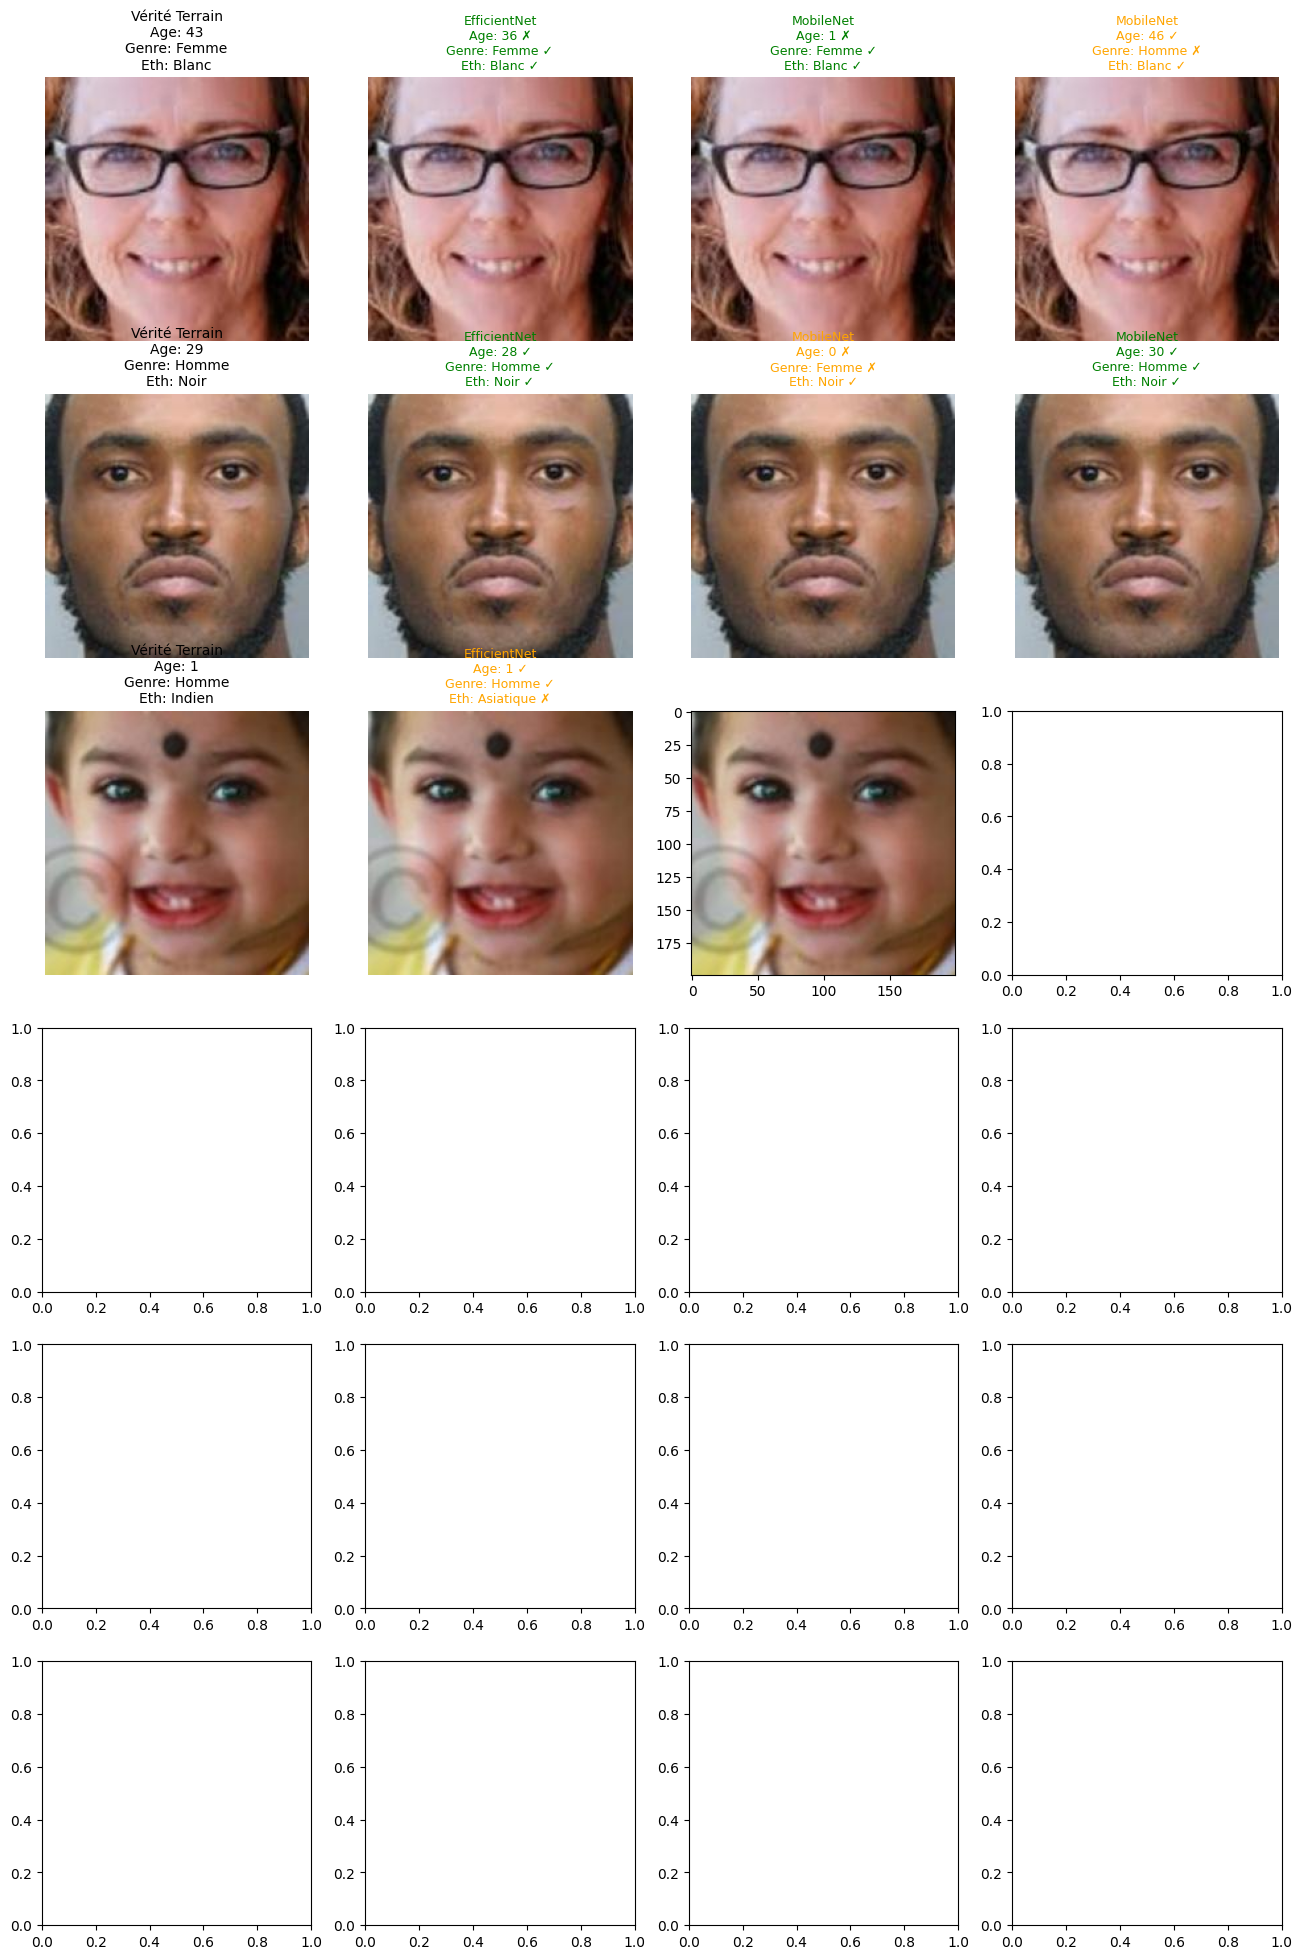

In [ ]:
# Afficher quelques exemples de prédictions
GENDER_LABELS = ["Homme", "Femme"]
ETH_LABELS = [
    "Blanc",
    "Noir",
    "Asiatique",
    "Indien",
    "Autres",
]  # 5 classes pour supporter tous les modèles


def show_predictions(indices, test_images, all_predictions, ground_truth):
    """Affiche les prédictions de tous les modèles pour des images données"""
    n_images = len(indices)
    n_models = len(all_predictions)

    fig, axes = plt.subplots(
        n_images, n_models + 1, figsize=(4 * (n_models + 1), 4 * n_images)
    )
    if n_images == 1:
        axes = axes.reshape(1, -1)

    for row, idx in enumerate(indices):
        img_path = test_images[idx][0]
        gt = ground_truth[idx]

        # Afficher l'image originale
        ax = axes[row, 0]
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(
            f"Vérité Terrain\nAge: {gt['age']}\n"
            f"Genre: {GENDER_LABELS[gt['gender']]}\n"
            f"Eth: {ETH_LABELS[gt['ethnicity']]}",
            fontsize=10,
        )
        ax.axis("off")

        # Afficher les prédictions de chaque modèle
        for col, (name, preds) in enumerate(all_predictions.items(), 1):
            ax = axes[row, col]
            pred = preds[idx]

            # Vérifier les prédictions correctes
            age_ok = abs(pred["age"] - gt["age"]) <= 5
            gender_ok = pred["gender"] == gt["gender"]
            eth_ok = pred["ethnicity"] == gt["ethnicity"]

            ax.imshow(img)
            title = f"{name.split()[0]}\n"
            title += f"Age: {pred['age']:.0f} {'✓' if age_ok else '✗'}\n"
            title += (
                f"Genre: {GENDER_LABELS[pred['gender']]} {'✓' if gender_ok else '✗'}\n"
            )
            title += f"Eth: {ETH_LABELS[pred['ethnicity']]} {'✓' if eth_ok else '✗'}"

            color = (
                "green"
                if (gender_ok and eth_ok)
                else ("orange" if (gender_ok or eth_ok) else "red")
            )
            ax.set_title(title, fontsize=9, color=color)
            ax.axis("off")

    plt.tight_layout()
    plt.savefig(
        "artifacts/prediction_comparison_examples.png", dpi=150, bbox_inches="tight"
    )
    plt.show()


# Afficher 6 exemples aléatoires
np.random.seed(123)
sample_indices = np.random.choice(len(test_images), 6, replace=False)
show_predictions(sample_indices, test_images, all_predictions, ground_truth)

## 7. Analyse des Erreurs par Catégorie


In [ ]:
# Analyse des erreurs par ethnicité
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, len(interpreters), figsize=(6 * len(interpreters), 5))

for idx, (name, predictions) in enumerate(all_predictions.items()):
    ax = axes[idx]
    pred_eth = [p["ethnicity"] for p in predictions]

    cm = confusion_matrix(true_ethnicities, pred_eth, labels=[0, 1, 2, 3])

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=ETH_LABELS,
        yticklabels=ETH_LABELS,
    )
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")
    ax.set_title(
        f"{name.split()[0]} - Ethnicité\nAcc: {accuracy_score(true_ethnicities, pred_eth)*100:.1f}%"
    )

plt.tight_layout()
plt.savefig(
    "artifacts/ethnicity_confusion_comparison.png", dpi=150, bbox_inches="tight"
)
plt.show()

In [ ]:
# Analyse des erreurs d'âge par tranche
age_ranges = [(0, 20), (20, 40), (40, 60), (60, 120)]
age_range_labels = ["0-20", "20-40", "40-60", "60+"]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(age_range_labels))
width = 0.25

for i, (name, predictions) in enumerate(all_predictions.items()):
    mae_by_range = []

    for low, high in age_ranges:
        indices = [j for j, gt in enumerate(ground_truth) if low <= gt["age"] < high]
        if indices:
            true_ages_range = [ground_truth[j]["age"] for j in indices]
            pred_ages_range = [predictions[j]["age"] for j in indices]
            mae = mean_absolute_error(true_ages_range, pred_ages_range)
            mae_by_range.append(mae)
        else:
            mae_by_range.append(0)

    bars = ax.bar(
        x + i * width, mae_by_range, width, label=name.split()[0], color=colors[i]
    )

ax.set_xlabel("Tranche d'âge", fontsize=12)
ax.set_ylabel("MAE (années)", fontsize=12)
ax.set_title("Erreur d'Âge par Tranche", fontsize=14, fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(age_range_labels)
ax.legend()

plt.tight_layout()
plt.savefig("artifacts/age_error_by_range.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Résumé et Recommandations


In [ ]:
# Créer un tableau récapitulatif avec scores
print("\n" + "=" * 80)
print("RÉSUMÉ COMPARATIF - MobileNet vs EfficientNet")
print("=" * 80)

summary_data = []
for result in evaluation_results:
    # Score global (pondéré)
    gender_acc_val = float(result["Genre Acc"].replace("%", "")) / 100
    eth_acc_val = float(result["Eth. Acc"].replace("%", "")) / 100
    age_mae_val = result["Age MAE"]
    time_val = result["Temps (ms)"]
    size_val = result["Taille (MB)"]

    # Score de précision (0-100)
    precision_score = (
        gender_acc_val * 35 + eth_acc_val * 35 + max(0, (15 - age_mae_val) / 15) * 30
    )

    # Score d'efficacité (0-100)
    efficiency_score = (
        max(0, (20 - time_val) / 20) * 50 + max(0, (15 - size_val) / 15) * 50
    )

    summary_data.append(
        {
            "Modèle": result["Modèle"],
            "Score Précision": f"{precision_score:.1f}/100",
            "Score Efficacité": f"{efficiency_score:.1f}/100",
            "Score Global": f"{(precision_score * 0.7 + efficiency_score * 0.3):.1f}/100",
            "Recommandation": "",
        }
    )

# Ajouter les recommandations
best_precision = max(
    summary_data, key=lambda x: float(x["Score Précision"].split("/")[0])
)
best_efficiency = max(
    summary_data, key=lambda x: float(x["Score Efficacité"].split("/")[0])
)
best_global = max(summary_data, key=lambda x: float(x["Score Global"].split("/")[0]))

for item in summary_data:
    recs = []
    if item["Modèle"] == best_precision["Modèle"]:
        recs.append("Meilleure précision")
    if item["Modèle"] == best_efficiency["Modèle"]:
        recs.append("Plus efficace")
    if item["Modèle"] == best_global["Modèle"]:
        recs.append("★ RECOMMANDÉ")
    item["Recommandation"] = " | ".join(recs) if recs else "-"

df_summary = pd.DataFrame(summary_data)
display(df_summary)

In [ ]:
# Conclusion visuelle
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot: Précision vs Efficacité
for i, result in enumerate(evaluation_results):
    gender_acc = float(result["Genre Acc"].replace("%", ""))
    eth_acc = float(result["Eth. Acc"].replace("%", ""))
    time_ms = result["Temps (ms)"]
    size_mb = result["Taille (MB)"]

    # X: Score combiné de précision (genre + ethnicité)
    precision = (gender_acc + eth_acc) / 2

    # Y: Score d'efficacité (inverse du temps * taille)
    efficiency = 100 / (time_ms * size_mb / 10)

    ax.scatter(
        precision, efficiency, s=300, c=colors[i], label=result["Modèle"], alpha=0.8
    )
    ax.annotate(
        result["Modèle"].split()[0],
        (precision, efficiency),
        textcoords="offset points",
        xytext=(0, 15),
        ha="center",
        fontsize=10,
    )

ax.set_xlabel("Précision Moyenne (Genre + Ethnicité) [%]", fontsize=12)
ax.set_ylabel("Score d'Efficacité (vitesse × légèreté)", fontsize=12)
ax.set_title(
    "Compromis Précision vs Efficacité\n(idéal: en haut à droite)",
    fontsize=14,
    fontweight="bold",
)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("artifacts/precision_vs_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusions

### Tableau Récapitulatif

| Critère       | EfficientNet V4 | MobileNet V1 | MobileNet V5 |
| ------------- | --------------- | ------------ | ------------ |
| **Précision** | ⭐⭐⭐          | ⭐⭐⭐       | ⭐⭐         |
| **Vitesse**   | ⭐⭐            | ⭐⭐         | ⭐⭐⭐       |
| **Taille**    | ⭐              | ⭐⭐         | ⭐⭐⭐       |
| **Mobile**    | Bon             | Bon          | Excellent    |

### Recommandations

1. **Pour la meilleure précision** : EfficientNet V4 ou MobileNet V1 Large
2. **Pour le déploiement mobile** : MobileNet V5 Small (3.5 MB)
3. **Compromis optimal** : MobileNet V1 Large

### Points Clés

- **MobileNetV3Small (V5)** est ~3x plus petit que EfficientNet mais avec une légère perte de précision
- **EfficientNetB0** reste le meilleur pour l'ethnicité
- Les temps d'inférence sont similaires sur CPU, mais MobileNet sera plus rapide sur mobile (optimisations spécifiques)
